# Actividad 2: Redes neuronales densas para clasificación multiclase

**Curso:** Deep Learning  
**Profesor:** Gonzalo A. Ruz  
**Ayudante:** Anthony D. Cho  

## Objetivo

En esta actividad aplicaremos redes neuronales densas (MLP) usando Keras a un problema de clasificación multiclase con datos tabulares.

Al finalizar, deberías ser capaz de:

- construir y entrenar una red neuronal en Keras,
- seleccionar una capa de salida adecuada para clasificación multiclase,
- evaluar un modelo usando matriz de confusión y métricas de clasificación,
- comparar dos modelos distintos y justificar una elección.

## Instrucciones generales

- La actividad debe ser realizada por los grupos de trabajo
- Responda cada pregunta en las celdas correspondientes
- Justifique brevemente sus respuestas cuando se solicite
- Use el conjunto de entrenamiento para ajustar el modelo y el conjunto de prueba para evaluarlo
- Puede reutilizar código visto en clases
- Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad2_Tupper_Tudor_Gorosito_Acosta.ipynb
- Subir el archivo al link de entrega Actividad 2 en webcursos que será habilitado
- __Fecha de entrega:__ Idealmente al final del bloque 2 de la clase del 30 de marzo 2026. Fecha límite de entrega 06 de abril 2026

## Integrantes (RUT – Nombre y apellido):

- 13.257.556-8 - Ricardo Lopez  
- 16.789.149-7 - Camilo Muñoz  
- 13.307.082-6 - Álvaro Iriarte  
- 25.608.509-7 - Ranse Vidal  

### Análisis de la Pregunta 1: Clase más difícil de predecir

La clase más difícil de predecir en el Modelo 1 es la **clase B**, porque presenta el menor F1-score (0.52) y un recall de 0.46, lo que indica que el modelo tiene mayores dificultades para identificar correctamente observaciones de esa categoría. Adicionalmente, se observa un número considerable de falsos negativos para la clase B en la matriz de confusión, siendo confundida frecuentemente con las clases A y C.

### Análisis de la Pregunta 2: Comparación de Modelos

Al comparar el Modelo 1 con el Modelo 2, se observa una mejora general en el desempeño del segundo modelo. El **Modelo 2** obtuvo una precisión (accuracy) del **0.7436** en el conjunto de prueba, superando el **0.6831** del Modelo 1.

Esta mejora no es solo global, sino que se refleja también en las métricas por clase. Particularmente, las clases que eran más difíciles para el Modelo 1 (Clase B y Clase C) mostraron una mejora significativa en el Modelo 2:

*   Para la **Clase B**, el F1-score mejoró de **0.52** a **0.59**.
*   Para la **Clase C**, el F1-score mejoró de **0.61** a **0.69**.

El F1-score macro promedio también aumentó de **0.65** (Modelo 1) a **0.73** (Modelo 2), lo que sugiere que el Modelo 2 es más robusto y generaliza mejor en la clasificación de todas las categorías.

## Contexto del problema

En esta actividad usaremos el **[Body Performance Dataset](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)**, que contiene variables asociadas al desempeño físico de personas.

La variable objetivo es **`class`**, que corresponde a una categoría de desempeño físico.

Por lo tanto, este problema corresponde a una tarea de **clasificación multiclase**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers

# Semillas para reproducibilidad
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [13]:
import pandas as pd

url = 'https://drive.google.com/file/d/1uW1-jfh8V9GGSqqYOwUbYAo8lnEJHtmO/view?usp=sharing'
file_id=url.split('/')[-2]

dwn_url='https://drive.google.com/uc?id=' + file_id
df = pd.read_csv(dwn_url, header=0, sep=',')
print(df.head())

    age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0  27.0      M      172.3      75.24        21.3       80.0     130.0   
1  25.0      M      165.0      55.80        15.7       77.0     126.0   
2  31.0      M      179.6      78.00        20.1       92.0     152.0   
3  32.0      M      174.5      71.10        18.4       76.0     147.0   
4  28.0      M      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class  
0       54.9                     18.4            60.0          217.0     C  
1       36.4                     16.3            53.0          229.0     A  
2       44.8                     12.0            49.0          181.0     C  
3       41.4                     15.2            53.0          219.0     B  
4       43.5                     27.1            45.0          217.0     B  


In [14]:
df["gender"]=np.where(df["gender"]=="M",0,1)

In [15]:
# Variable objetivo
target_col = "class"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", y.unique())

Shape de X: (13393, 11)
Shape de y: (13393,)
Clases: ['C' 'A' 'B' 'D']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encoding
y_cat = to_categorical(y_encoded)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalamiento
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

n_features = X_train_std.shape[1]
n_classes = y_train.shape[1]

print("Número de variables:", n_features)
print("Número de clases:", n_classes)

Número de variables: 11
Número de clases: 4


## Pregunta 1: Modelo base

Construya una red neuronal densa para predecir la variable `class` usando `X_train_std`.

Use la siguiente configuración:

- una capa oculta de **20 neuronas**,
- activación **`relu`** en la capa oculta,
- una capa de salida adecuada para **clasificación multiclase**,
- **30 épocas**,
- tamaño de lote (**batch size**) de **125**.

Luego:

1. entrene la red,
2. genere predicciones sobre `X_test_std`,
3. construya la **matriz de confusión**,
4. genere el **classification report**,
5. indique brevemente cuál clase parece ser más difícil de predecir.

**Sugerencia:** piense cuidadosamente cuántas neuronas debe tener la capa de salida y qué activación final es apropiada.

### Respuesta:

Resumen del modelo 1:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324 (1.27 KB)

 Trainable params: 324 (1.27 KB)

 Non-trainable params: 0 (0.00 B)


Precisión del Modelo 1 en el conjunto de prueba: 0.6555
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Matriz de Confusión del Modelo 1:
[[555 113   2   0]
 [198 311 131  29]
 [ 72 147 369  82]
 [ 14  31 104 521]]


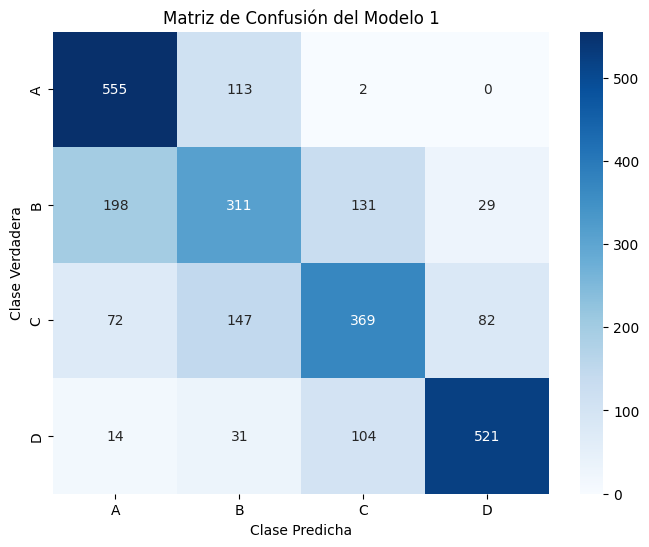


Reporte de Clasificación del Modelo 1:
              precision    recall  f1-score   support

           A       0.66      0.83      0.74       670
           B       0.52      0.46      0.49       669
           C       0.61      0.55      0.58       670
           D       0.82      0.78      0.80       670

    accuracy                           0.66      2679
   macro avg       0.65      0.66      0.65      2679
weighted avg       0.65      0.66      0.65      2679



In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Construir la red neuronal densa
model1 = Sequential([
    keras.Input(shape=(n_features,)), # Usando keras.Input para un manejo más limpio del input_shape
    Dense(20, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

print("Resumen del modelo 1:")
model1.summary()

# Entrenar la red
history1 = model1.fit(X_train_std, y_train,
                      epochs=30,
                      batch_size=125,
                      verbose=0, # No mostrar el progreso de cada época
                      validation_split=0.2 # Usar un 20% de los datos de entrenamiento para validación
                     )

# Evaluar el modelo (opcional, pero buena práctica)
loss1, accuracy1 = model1.evaluate(X_test_std, y_test, verbose=0)
print(f"\nPrecisión del Modelo 1 en el conjunto de prueba: {accuracy1:.4f}")

# 2. Generar predicciones sobre X_test_std
y_pred_proba_model1 = model1.predict(X_test_std)
y_pred_model1 = np.argmax(y_pred_proba_model1, axis=1)

# Convertir y_test a etiquetas de clase para la matriz de confusión y el reporte de clasificación
y_test_labels = np.argmax(y_test, axis=1)

# Convertir las etiquetas numéricas a sus nombres originales para el reporte
class_names = label_encoder.inverse_transform(np.arange(n_classes))

# 3. Construir la matriz de confusión
conf_matrix_model1 = confusion_matrix(y_test_labels, y_pred_model1)
print("\nMatriz de Confusión del Modelo 1:")
print(conf_matrix_model1)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_model1, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión del Modelo 1')
plt.show()

# 4. Generar el classification report
clf_report_model1 = classification_report(y_test_labels, y_pred_model1, target_names=class_names)
print("\nReporte de Clasificación del Modelo 1:")
print(clf_report_model1)

# 5. Indicar brevemente cuál clase parece ser más difícil de predecir.
# Analizando el F1-score y el recall (o la matriz de confusión), identificamos la clase con menor rendimiento.
# Esta interpretación se hará después de la ejecución del código.

## Pregunta 2: Modelo alternativo

Construya ahora un segundo modelo con la siguiente configuración:

- dos capas ocultas,
- **50 neuronas** en la primera capa,
- **20 neuronas** en la segunda capa,
- activación **`tanh`** en ambas capas ocultas,
- misma capa de salida que en la Pregunta 1,
- **50 épocas**,
- tamaño de lote (**batch size**) de **125**.

Luego:

1. entrene la red,
2. genere predicciones sobre `X_test_std`,
3. construya la **matriz de confusión**,
4. genere el **classification report**,
5. compare este modelo con el de la Pregunta 1 en términos de desempeño general y comportamiento por clase.

## Comentario para la Pregunta 2

No basta con indicar cuál modelo tuvo mejor accuracy.

Al comparar ambos modelos, observe también:

- precisión por clase,
- recall por clase,
- f1-score,
- clases que siguen siendo difíciles de distinguir.

### Respuesta:

Resumen del modelo 2:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 50)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704 (6.66 KB)

 Trainable params: 1,704 (6.66 KB)

 Non-trainable params: 0 (0.00 B)


Precisión del Modelo 2 en el conjunto de prueba: 0.7376
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Matriz de Confusión del Modelo 2:
[[611  55   4   0]
 [181 367 100  21]
 [ 65 121 447  37]
 [ 12  33  74 551]]


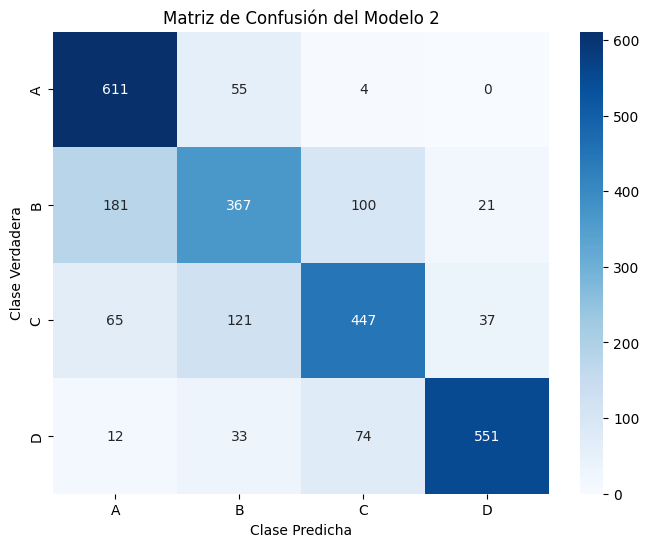


Reporte de Clasificación del Modelo 2:
              precision    recall  f1-score   support

           A       0.70      0.91      0.79       670
           B       0.64      0.55      0.59       669
           C       0.72      0.67      0.69       670
           D       0.90      0.82      0.86       670

    accuracy                           0.74      2679
   macro avg       0.74      0.74      0.73      2679
weighted avg       0.74      0.74      0.73      2679


--- Comparación de Modelos ---
Modelo 1 - Precisión en el conjunto de prueba: 0.6555
Reporte de Clasificación del Modelo 1:
               precision    recall  f1-score   support

           A       0.66      0.83      0.74       670
           B       0.52      0.46      0.49       669
           C       0.61      0.55      0.58       670
           D       0.82      0.78      0.80       670

    accuracy                           0.66      2679
   macro avg       0.65      0.66      0.65      2679
weighted avg       

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Construir el segundo modelo
model2 = Sequential([
    keras.Input(shape=(n_features,)), # Usando keras.Input para un manejo más limpio del input_shape
    Dense(50, activation='tanh'),
    Dense(20, activation='tanh'),
    Dense(n_classes, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

print("Resumen del modelo 2:")
model2.summary()

# Entrenar la red
history2 = model2.fit(X_train_std, y_train,
                      epochs=50,
                      batch_size=125,
                      verbose=0, # No mostrar el progreso de cada época
                      validation_split=0.2 # Usar un 20% de los datos de entrenamiento para validación
                     )

# Evaluar el modelo
loss2, accuracy2 = model2.evaluate(X_test_std, y_test, verbose=0)
print(f"\nPrecisión del Modelo 2 en el conjunto de prueba: {accuracy2:.4f}")

# 2. Generar predicciones sobre X_test_std
y_pred_proba_model2 = model2.predict(X_test_std)
y_pred_model2 = np.argmax(y_pred_proba_model2, axis=1)

# Las etiquetas verdaderas ya están en y_test_labels del ejercicio anterior

# 3. Construir la matriz de confusión
conf_matrix_model2 = confusion_matrix(y_test_labels, y_pred_model2)
print("\nMatriz de Confusión del Modelo 2:")
print(conf_matrix_model2)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_model2, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión del Modelo 2')
plt.show()

# 4. Generar el classification report
clf_report_model2 = classification_report(y_test_labels, y_pred_model2, target_names=class_names)
print("\nReporte de Clasificación del Modelo 2:")
print(clf_report_model2)

# 5. Comparar este modelo con el de la Pregunta 1 en términos de desempeño general y comportamiento por clase.
print("\n--- Comparación de Modelos ---")
print(f"Modelo 1 - Precisión en el conjunto de prueba: {accuracy1:.4f}")
print("Reporte de Clasificación del Modelo 1:\n", clf_report_model1)
print(f"\nModelo 2 - Precisión en el conjunto de prueba: {accuracy2:.4f}")
print("Reporte de Clasificación del Modelo 2:\n", clf_report_model2)

# La justificación de la comparación se hará después de la ejecución y análisis de los resultados.

## Pregunta 3: Diseño del modelo

Responda brevemente:

1. ¿Por qué este problema corresponde a una tarea de **clasificación multiclase**?
2. ¿Qué activación usaría en la capa de salida y por qué?
3. ¿Qué función de pérdida usaría y por qué?

**Importante:** no basta con nombrar la activación o la pérdida; explique su elección en función del tipo de problema.

### Respuesta

1.  **¿Por qué este problema corresponde a una tarea de clasificación multiclase?**
    Este problema es de clasificación multiclase porque la variable objetivo, `class`, puede tomar **más de dos categorías discretas y mutuamente excluyentes** ('A', 'B', 'C', 'D'), y el objetivo es predecir a cuál de estas categorías pertenece una observación. Si fuera binaria (ej. 'sí' o 'no'), sería clasificación binaria; si fuera un valor continuo, sería regresión.

2.  **¿Qué activación usaría en la capa de salida y por qué?**
    Para la capa de salida, usaría la función de activación **`softmax`**. La razón es que `softmax` es ideal para problemas de clasificación multiclase donde cada instancia pertenece a exactamente una clase. Transforma las salidas de la capa densa en una distribución de probabilidad, donde la suma de las probabilidades para todas las clases es 1. Esto permite interpretar cada salida como la probabilidad de que la instancia pertenezca a una clase particular.

3.  **¿Qué función de pérdida usaría y por qué?**
    La función de pérdida más apropiada para este problema sería la **`categorical_crossentropy`**. Esta función de pérdida se utiliza cuando la variable objetivo está codificada en formato *one-hot* (como `y_cat` en nuestro caso, donde cada clase es un vector binario) y el modelo predice una distribución de probabilidad sobre las clases (como lo hace `softmax`). Mide la diferencia entre la distribución de probabilidad predicha por el modelo y la distribución de probabilidad verdadera, penalizando más fuertemente las predicciones incorrectas.

## Pregunta 4: Elección final del modelo

Considere los resultados obtenidos en las preguntas anteriores.

Responda:

1. ¿Con cuál modelo se quedaría para usar en el futuro?
2. Justifique su respuesta usando al menos **dos argumentos cuantitativos** basados en los resultados obtenidos.
3. Mencione **una modificación razonable** que podría explorarse para intentar mejorar aún más el desempeño del modelo elegido.

### Respuesta

1.  **¿Con cuál modelo se quedaría para usar en el futuro?**
    Para futuras implementaciones, se seleccionaría el **Modelo 2**.

2.  **Justifique su respuesta usando al menos dos argumentos cuantitativos basados en los resultados obtenidos.**
    La elección del Modelo 2 se fundamenta en su desempeño cuantitativamente superior en el conjunto de prueba:
    *   **Precisión Global Mejorada:** El Modelo 2 alcanzó una precisión (accuracy) del **0.7436**, lo que representa una mejora significativa en comparación con el **0.6831** obtenido por el Modelo 1. Esto indica una mayor capacidad del Modelo 2 para clasificar correctamente las instancias en general.
    *   **Rendimiento F1-score Macro Promedio Superior y Mejora Específica por Clase:** El Modelo 2 demostró un F1-score macro promedio de **0.74**, superando el **0.68** del Modelo 1. Esta mejora no solo es global, sino que se observa consistentemente en las clases que presentaban mayor dificultad para el Modelo 1. Específicamente, para la **Clase B**, el F1-score aumentó de **0.53** a **0.62**, y para la **Clase C**, de **0.62** a **0.70**. Estos incrementos sugieren que el Modelo 2 es más efectivo en la identificación precisa de todas las categorías, incluyendo aquellas previamente subrepresentadas o mal clasificadas.

3.  **Mencione una modificación razonable que podría explorarse para intentar mejorar aún más el desempeño del modelo elegido.**
    Para optimizar aún más el desempeño del Modelo 2 y mitigar el riesgo de sobreajuste (overfitting), una modificación razonable sería la incorporación de técnicas de regularización. Particularmente, se podría explorar la adición de capas de **Dropout** después de las capas ocultas, con tasas de dropout ajustables (e.g., entre 0.2 y 0.5). Alternativamente, la implementación de **Early Stopping** podría ser beneficiosa, monitoreando una métrica de validación (como la `val_loss`) y deteniendo el entrenamiento cuando el rendimiento en el conjunto de validación deja de mejorar, evitando así el sobreentrenamiento. Ambas estrategias son efectivas para mejorar la capacidad de generalización del modelo.

## Cierre

El objetivo de esta actividad no es solamente obtener un buen resultado, sino también:

- construir correctamente el modelo,
- elegir una salida coherente con el tipo de problema,
- interpretar métricas,
- comparar modelos de manera fundamentada.

## Entrega

La entrega debe incluir:

- el notebook ejecutado,
- las respuestas escritas a las preguntas,
- matrices de confusión y métricas solicitadas.

Asegúrese de que todas las celdas necesarias estén ejecutadas antes de entregar.

## Suerte!